# Machine Translation Project: Russian to English (Biomedical Domain)

This Jupyter Notebook serves as an **organized workflow** for training and evaluating a **Neural Machine Translation (NMT) model** using **Sequence-to-Sequence with Attention**.

In [ ]:
# Clone repo from github
#!git clone https://fboglind@github.com/fboglind/lab4_mt_project.git

In [ ]:
# Install dependencies (if not installed)
#!pip install torch pandas matplotlib seaborn sentencepiece sacrebleu

## **1. Create parallel corpus and test set**
- Reads files containing abstracts
- Creates a parallel corpus
- Creates a test set

In [ ]:
# Creating parallel corpus and test set
!mkdir -p data
!python3 scripts/preprocess_wmt22.py

## **2. Load & Explore Data**


- Load the parallel corpus
- Analyze text length distributions
- Check for alignment issues
- Clean the data

                                                  Russian  \
count                                               11152   
unique                                              11150   
top     Проанализировано качество оказания помощи паци...   
freq                                                    2   

                                                  English  
count                                               11152  
unique                                              11144  
top     The aim of the study was to elaborate lingual ...  
freq                                                    2  
                                             Russian  \
0  Резюме Цель: Определить, в какой степени грипп...   
1  Резюме Цель: Провести экспертную процедуру опр...   
2  Резюме Цель: Определить влияние еженедельной н...   
3  Резюме Цель: Определить, явилась ли политика б...   
4  Резюме Цель: Оценить проблему туберкулеза со м...   

                                             English  
0 

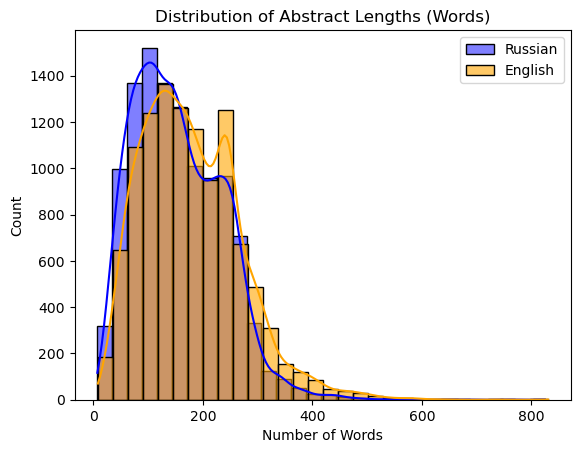

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/parallel_corpus.tsv", sep="\t", encoding="utf-8")

# Basic statistics
print(df.describe())
print(df.head())

# Plot text length distributions
df["Russian_Length"] = df["Russian"].apply(lambda x: len(x.split()))
df["English_Length"] = df["English"].apply(lambda x: len(x.split()))

sns.histplot(df["Russian_Length"], bins=30, kde=True, label="Russian", color="blue")
sns.histplot(df["English_Length"], bins=30, kde=True, label="English", color="orange", alpha=0.6)
plt.legend()
plt.title("Distribution of Abstract Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

Let's remove some of the 'misaligned' abstracts, while also perform some basic cleaning

In [110]:
!python3 scripts/clean_parallel_corpus.py --input data/parallel_corpus.tsv --output data/cleaned_parallel_corpus_initial.tsv

Cleaned parallel corpus saved to data/cleaned_parallel_corpus_initial.tsv


In [111]:
# Check the cleaned data
df = pd.read_csv("data/cleaned_parallel_corpus_initial.tsv", sep="\t", encoding="utf-8")
# Display one column per row for the first lines of the dataframe
for index, row in df.head(10).iterrows():
    print(f"Row {index}:")
    print(f"Russian: {row['Russian']}")
    print(f"English: {row['English']}")
    print(f"Russian_Length: {row['Russian_Length']}")
    print(f"English_Length: {row['English_Length']}")
    print("-" * 50)

Row 0:
Russian: Резюме Цель: Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя. Результаты: Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возрасте до 5 лет, составили 6,7 (95% доверительный интервал, ДИ: 0-18,3); 4,4 (95

Just by looking at the first lines we can see that the Russian text contain some Opening phrases that have no counterpart in the English text. We therefore scan the text for such common opening phrases while also checking if they have any corresponding English phrases:

In [112]:
!python3 scripts/extract_openers_from_english.py


🔹 Russian Opener: ^Цель исследования  (Count: 2402)
   to study the                             264
   the objective of                         200
   to evaluate the                          161
   the aim of                               133
   to assess the                            91
   to investigate the                       85
   to analyze the                           68
   to determine the                         66
   the purpose of                           58
   to estimate the                          43

🔹 Russian Opener: ^Цель работы  (Count: 268)
   the objective of                         133
   the purpose of                           30
   the aim of                               24
   to study the                             5
   the study was                            4
   to evaluate the                          4
   to improve the                           3
   to analyze the                           3
   to assess the                            3
   aim of

Let's remove these opening phrases from the Russian texts together with common headers (i e Результаты и обсуждение - results and discussion etc.) as these are not present in the English text either.

In [116]:
!python3 scripts/clean_russian_openers.py
!head data/cleaned_parallel_corpus.tsv

Cleaned file saved to: data/cleaned_parallel_corpus.tsv
Russian	English	Russian_Length	English_Length	Length_Ratio
Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя.  Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возраст

Abstracts are quite long, we therefore split them into sentences before further tokenization.

In [117]:
!python3 scripts/split_abstracts.py --input data/cleaned_parallel_corpus.tsv --output data/sentence_aligned_corpus.tsv

Sentence-aligned corpus saved to data/sentence_aligned_corpus.tsv


In [118]:
# Check for misaligned sentences
import pandas as pd
df = pd.read_csv("data/sentence_aligned_corpus.tsv", sep="\t", encoding="utf-8")

# Check for misaligned rows
misaligned = df[(df["Russian"].str.len() < 10) | (df["English"].str.len() < 10)]
print(f"⚠️ Found {len(misaligned)} potentially broken rows.")

# Check for newline artifacts
newline_issues = df[df["Russian"].str.contains("\n") | df["English"].str.contains("\n")]
print(f"🔍 Found {len(newline_issues)} rows with embedded newlines.")


⚠️ Found 0 potentially broken rows.
🔍 Found 0 rows with embedded newlines.


Let's scan the Russian text for Latin terms

In [120]:
import re

def contains_latin(text):
    return bool(re.search(r"[A-Za-z]{2,}", text))

# Filter or flag those rows
df_with_latin = df[df["Russian"].apply(contains_latin)]
print(f"🔍 Found {len(df_with_latin)} rows with Latin characters in Russian.")

for i, row in df.iterrows():
    if contains_latin(row["Russian"]):
        print(f"[{i}] {row['Russian']}")


🔍 Found 4624 rows with Latin characters in Russian.
[1] Провести экспертную процедуру определения научно-исследовательских приоритетов в области сексуального и репродуктивного здоровья подростков в странах с низким и средним уровнем доходов. Методы: Авторы изменили метод определения приоритетов Инициативы по исследованиям детского здоровья и питания (CHNRI) для получения информации приблизительно от 300 исследователей, доноров и руководителей программ здравоохранения, обладающих обширными знаниями и опытом, со всех географических регионов мира. В ходе трехступенчатой процедуры экспертов просили: (i) оценить целевые области по степени важности; (ii) сформулировать исследовательские вопросы по каждой области и (iii) расставить сформулированные вопросы в порядке приоритетности.  Семь важных областей сексуального и репродуктивного здоровья подростков были определены как важные: (i) материнское здоровье; (ii) контрацепция; (iii) гендерное насилие; (iv) лечение и уход за пациентами с вирусом

In [123]:
!python3 extract_latin_terms.py

Top Latin-script terms:
sub                  1038
sup                  758
II                   460
III                  362
COVID-19             320
in                   198
IV                   192
D-                   133
CD4                  102
MMSE                 100
of                   99
Ki-67                99
vitro                94
PubMed               91
NIHSS                91
VEGF                 91
PANSS                89
I-II                 82
pylori               81
SF-36                76
BDNF                 75
TNF-                 71
VEGF-                71
S100                 66
IL-6                 64
IgG                  64
Grade                63
II-III               62
ROC-                 62
vivo                 60
L-                   60
p0                   59
ii                   56
OR                   54
spp                  53
HER2                 53
SARS-CoV-2           53
Wistar               52
IL-                  51
iii                  50
HbA1 

We extract only the russian part of the corpus, as we'll need it later

In [ ]:
!python3 extract_russian.py --input data/sentence_aligned_corpus.tsv --output data/russian_only.txt

In [ ]:
!head -n5 data/russian_only.txt

## **3. Preprocessing: SentencePiece Tokenization**

- Extract source language data
- Train a SentencePiece model
- Tokenize the training and test sets

In [ ]:
import sentencepiece as spm

# Train SentencePiece. Output: spm_ru_only.model, spm_ru_only.vocab
!python3 scripts/sentencepiece_train.py --to_parallel

In [ ]:
!head -n20 models/spm_ru_joint.vocab

In [ ]:
# Apply SentencePiece Tokenization
!python3 scripts/apply_sentencepiece.py --input data/sentence_aligned_corpus.tsv --output data/spm_parallel_corpus.tsv --model models/spm_ru_only.model

In [ ]:
!head -n 5 data/spm_parallel_corpus.tsv

We must also tokenize the test set

In [ ]:
!python3 scripts/apply_sentencepiece.py --input data/test_raw_ru.txt --output data/spm_test_set.tsv --model models/spm_ru_only.model --is_test_set

In [ ]:
!head -n 5 data/spm_test_set.tsv

## **4. Model Training**

- Train the sequence-to-sequence model
- Use label smoothing to improve training stability
- Save the trained model

In [ ]:
# Train the model
!python3 scripts/seq2seq_train.py

## **5. Translation & Evaluation**

- Translate test data
- Evaluate performance using BLEU and chrF

In [ ]:
# Translate test set
!python3 scripts/translate_wmt_test.py

In [ ]:
# Evaluate translations
!python3 scripts/evaluate_translations.py --hyp data/wmt_test_translations_with_beam.txt --ref data/test_reference_en.txt
print("Project setup complete! Ready for further analysis.")

## **6. Next Steps & Improvements**

- Compare GRU vs. LSTM architectures
- Improve handling of long sequences (segmenting abstracts)
- Fine-tune hyperparameters for better results